In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications import vgg19

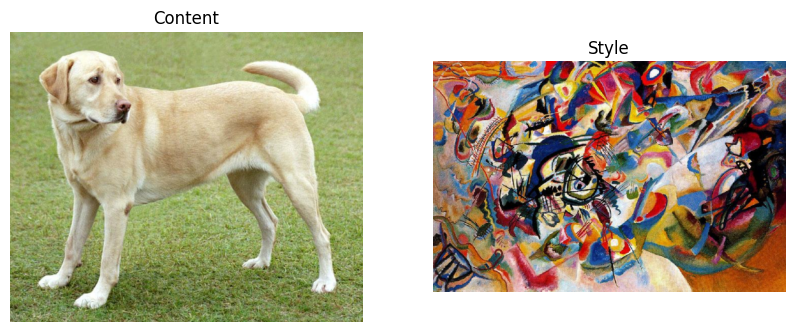

In [ ]:
CONTENT_PATH = tf.keras.utils.get_file(
    "content.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg",
)
STYLE_PATH = tf.keras.utils.get_file(
    "style.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg",
)

def load_img(path, max_dim=512):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    scale = max_dim / tf.reduce_max(shape)
    img = tf.image.resize(img, tf.cast(shape * scale, tf.int32))
    return img[tf.newaxis, :]

def show(img, title=None):
    plt.imshow(img[0].numpy())
    plt.axis("off")
    if title:
        plt.title(title)

content_image = load_img(CONTENT_PATH)
style_image = load_img(STYLE_PATH)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); show(content_image, "Content")
plt.subplot(1, 2, 2); show(style_image, "Style")
plt.show()

In [ ]:
content_layers = ["block5_conv2"]
style_layers = ["block1_conv1", "block2_conv1", "block3_conv1",
                "block4_conv1", "block5_conv1"]

def gram_matrix(x):
    g = tf.linalg.einsum("bijc,bijd->bcd", x, x)
    n = tf.cast(tf.shape(x)[1] * tf.shape(x)[2], tf.float32)
    return g / n

class StyleContentModel(tf.keras.Model):
    def __init__(self):
        super().__init__()
        vgg = vgg19.VGG19(include_top=False, weights="imagenet")
        vgg.trainable = False
        outputs = [vgg.get_layer(n).output for n in style_layers + content_layers]
        self.vgg = tf.keras.Model(vgg.input, outputs)

    def call(self, inputs):
        x = vgg19.preprocess_input(inputs * 255.0)
        outs = self.vgg(x)
        style_outs = outs[:len(style_layers)]
        content_outs = outs[len(style_layers):]
        return {
            "style": {n: gram_matrix(o) for n, o in zip(style_layers, style_outs)},
            "content": {n: o for n, o in zip(content_layers, content_outs)},
        }

extractor = StyleContentModel()
style_targets = extractor(style_image)["style"]
content_targets = extractor(content_image)["content"]

In [ ]:
style_weight = 1e-2
content_weight = 1e4
tv_weight = 30

image = tf.Variable(content_image)
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

def total_loss(outputs):
    style_loss = tf.add_n([
        tf.reduce_mean((outputs["style"][n] - style_targets[n]) ** 2)
        for n in style_layers
    ]) * style_weight / len(style_layers)
    content_loss = tf.add_n([
        tf.reduce_mean((outputs["content"][n] - content_targets[n]) ** 2)
        for n in content_layers
    ]) * content_weight / len(content_layers)
    return style_loss + content_loss

@tf.function
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = total_loss(outputs) + tv_weight * tf.reduce_sum(
            tf.image.total_variation(image))
    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, 0.0, 1.0))
    return loss

In [ ]:
EPOCHS, STEPS = 10, 100
for epoch in range(EPOCHS):
    for _ in range(STEPS):
        loss = train_step(image)
    print(f"Epoch {epoch + 1}/{EPOCHS}  loss = {float(loss):.1f}")

Epoch 1/10  loss = 37911104.0
Epoch 2/10  loss = 20465632.0
Epoch 3/10  loss = 14215850.0
Epoch 4/10  loss = 11200364.0
Epoch 5/10  loss = 9399550.0
Epoch 6/10  loss = 8258570.5
Epoch 7/10  loss = 7501319.0
Epoch 8/10  loss = 6976378.0
Epoch 9/10  loss = 6605319.0
Epoch 10/10  loss = 6327168.5


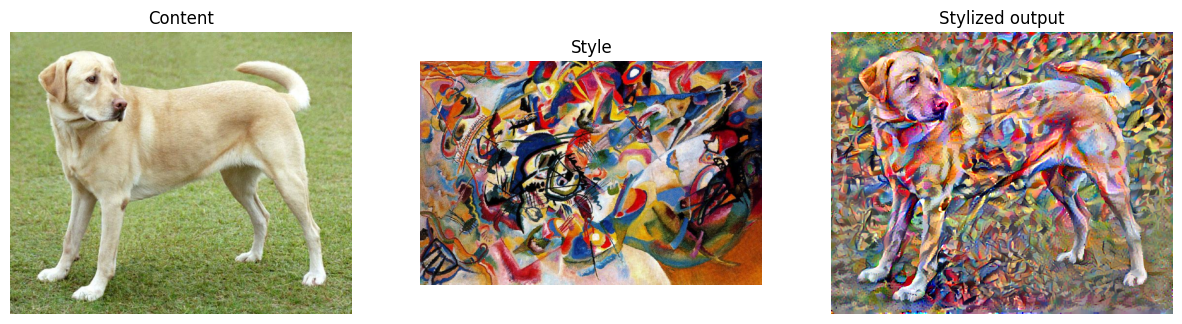

In [12]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); show(content_image, "Content")
plt.subplot(1, 3, 2); show(style_image, "Style")
plt.subplot(1, 3, 3); show(image, "Stylized output")
plt.show()

out = (image[0].numpy() * 255).astype(np.uint8)
Image.fromarray(out).save("stylized_output.png")